
Gravity Details

Acceleration of gravity at surface level:    9.7803 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5379 m/s²


Launch Site Details

Launch Site Latitude: 0.00000°
Launch Site Longitude: 0.00000°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 166021.44 W|E    0.00 N
Launch Site UTM zone: 31N
Launch Site Surface Elevation: 0.0 m


Atmospheric Model Details

Atmospheric Model Type: custom_atmosphere
custom_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 2.45 m/s
Surface Wind Direction: 246.00°
Surface Wind Heading: 66.00°
Surface Pressure: 925.00 hPa
Surface Temperature: 286.80 K
Surface Air Density: 1.124 kg/m³
Surface Speed of Sound: 339.50 m/s


Earth Model Details

Earth Radius at Launch site: 6378.14 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



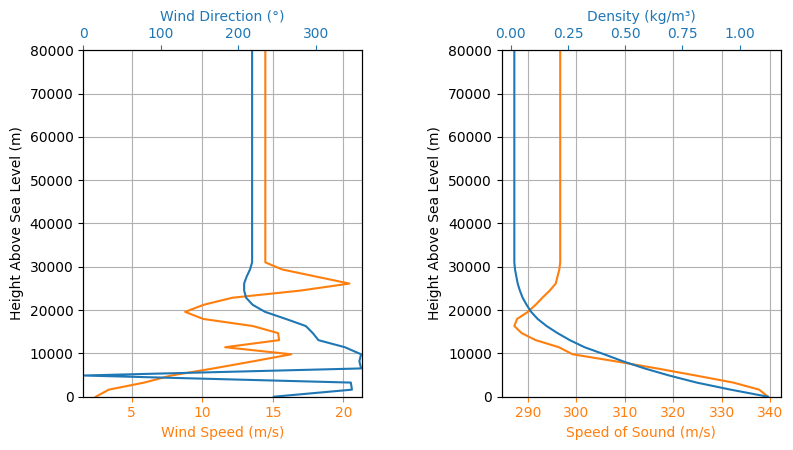

In [26]:
from rocketpy import Environment, SolidMotor, Rocket, Flight, Function
import datetime
import csv
import pandas as pd
import numpy as np

# Launch site
# FAR
# Latitude: 35.3466 N
# Longitude: -117.809 W
# Altitude: 2000 ft

site_lat = 35.3466
site_lon = -117.809 
site_alt = 2000 #ft

launch_date = [2026,1,18,8,0,0]
timeadj = -4


# Launch site
# FAR
# Latitude: 35.3466 N
# Longitude: -117.809 W
# Altitude: 2000 ft

site_lat = 35.3466
site_lon = -117.809 
site_alt = 2000/3.281 #ft

env = Environment()

# Load the .csv file into the environment
df = pd.read_csv('vertical_profile_2026-01-15_14PST copy.csv')

#print(df)

# Create Function objects to represent the profiles
pressure_func = Function(np.column_stack([df['height'], df['pressure']]))
temperature_func = Function(np.column_stack([df['height'], df['temperature']]))
wind_u_func = Function(np.column_stack([df['height'], df['wind_u']]))
wind_v_func = Function(np.column_stack([df['height'], df['wind_v']]))

# Set up the environment

env.set_atmospheric_model(
    type="custom_atmosphere",
    pressure=pressure_func,
    temperature=temperature_func,
    wind_u=wind_u_func,
    wind_v=wind_v_func,
)

# env = Environment(latitude=site_lat, longitude=site_lon, elevation=site_alt,date=(2026, 6, 7, 8)) # year, month, day, hour
# # timezone="US/Pacific")

# # env.set_atmospheric_model(type="Forecast", file="GFS")

# env.set_atmospheric_model(type="Windy", file="ICON")

env.info()


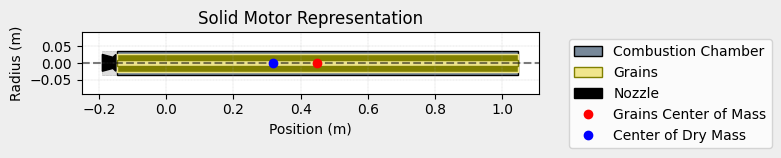

Nozzle Details
Nozzle Radius: 0.025 m
Nozzle Throat Radius: 0.0165 m

Grain Details
Number of Grains: 1
Grain Spacing: 0.001 m
Grain Density: 1815 kg/m3
Grain Outer Radius: 0.027 m
Grain Inner Radius: 0.008 m
Grain Height: 1.193 m
Grain Volume: 0.002 m3
Grain Mass: 4.524 kg

Motor Details
Total Burning Time: 4.3462 s
Total Propellant Mass: 4.524 kg
Structural Mass Ratio: 0.000
Average Propellant Exhaust Velocity: 2274.166 m/s
Average Thrust: 2367.015 N
Maximum Thrust: 4333.1866 N at 2.8997 s after ignition.
Total Impulse: 10287.519 Ns



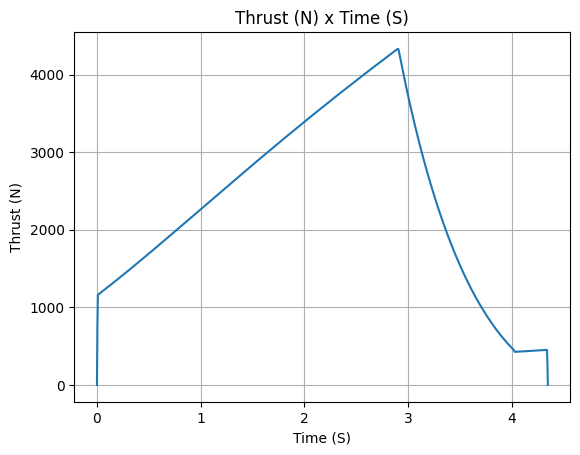

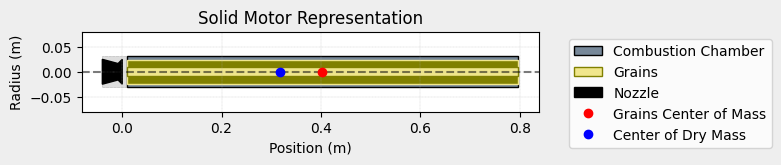

Nozzle Details
Nozzle Radius: 0.025 m
Nozzle Throat Radius: 0.0165 m

Grain Details
Number of Grains: 1
Grain Spacing: 0.001 m
Grain Density: 1815 kg/m3
Grain Outer Radius: 0.0238 m
Grain Inner Radius: 0.0095 m
Grain Height: 0.787 m
Grain Volume: 0.001 m3
Grain Mass: 2.137 kg

Motor Details
Total Burning Time: 2.054 s
Total Propellant Mass: 2.137 kg
Structural Mass Ratio: 0.000
Average Propellant Exhaust Velocity: 2236.119 m/s
Average Thrust: 2326.355 N
Maximum Thrust: 4272.2525 N at 0.89 s after ignition.
Total Impulse: 4778.334 Ns



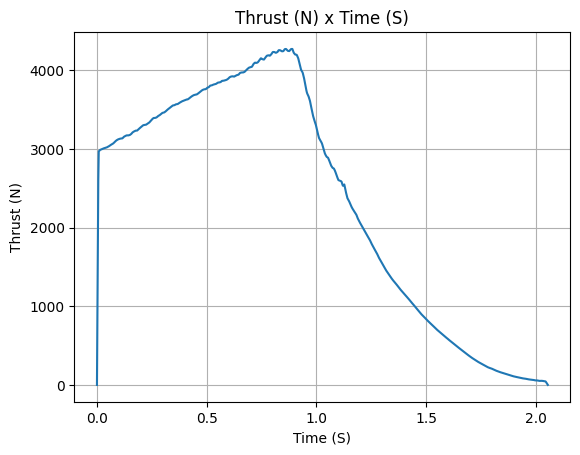

In [31]:

BoosterMotor = SolidMotor(
thrust_source="./fuckyourfins.eng",
dry_mass=0, #kg
dry_inertia=(0.125, 0.125, 0.002), #moi ,kg/m^2
nozzle_radius=25 / 1000, #m
grain_number=1, #m
grain_density=1815, #kg/m^3
grain_outer_radius=27 / 1000, #m
grain_initial_inner_radius= 8 / 1000, #m
grain_initial_height=1193 / 1000, #m
grain_separation=1 / 1000, #m 
grains_center_of_mass_position=0.45, #m
center_of_dry_mass_position=0.317, #m
nozzle_position=-0.19, #m
#burn_time=2.1, #s
throat_radius=16.5 / 1000,#m
coordinate_system_orientation="nozzle_to_combustion_chamber"
)
BoosterMotor.draw()
BoosterMotor.info()

SustainerMotor = SolidMotor(
thrust_source="./chuncmotor.eng",
dry_mass=0, #kg
dry_inertia=(0.125, 0.125, 0.002), #moi ,kg/m^2
nozzle_radius=25 / 1000, #m
grain_number=1, #m
grain_density=1815, #kg/m^3
grain_outer_radius=23.8 / 1000, #m
grain_initial_inner_radius= 9.5 / 1000, #m
grain_initial_height=787 / 1000, #m
grain_separation=1 / 1000, #m 
grains_center_of_mass_position=0.403, #m
center_of_dry_mass_position=0.317, #m
nozzle_position=-0.04, #m
#burn_time=3.5, #s
throat_radius=16.5 / 1000,#m
coordinate_system_orientation="nozzle_to_combustion_chamber",

)
SustainerMotor.draw()
SustainerMotor.info()
#SustainerMotor.info()


0.2917155456
0.0081032096


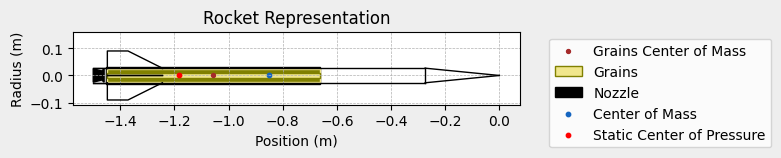

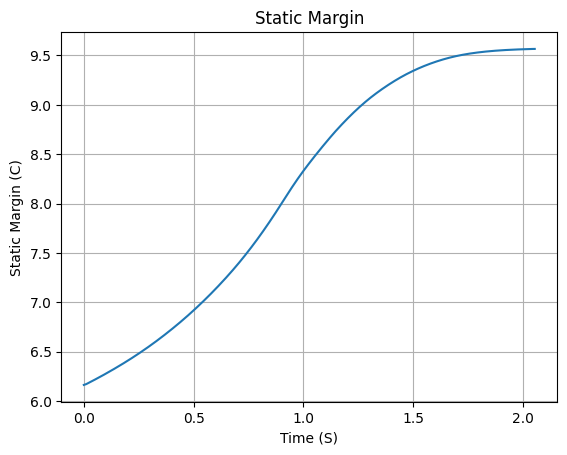

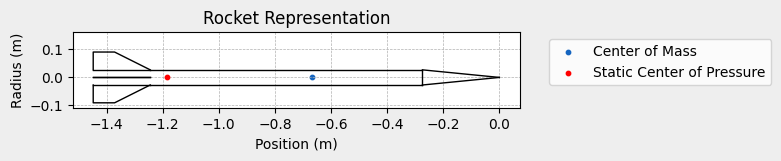

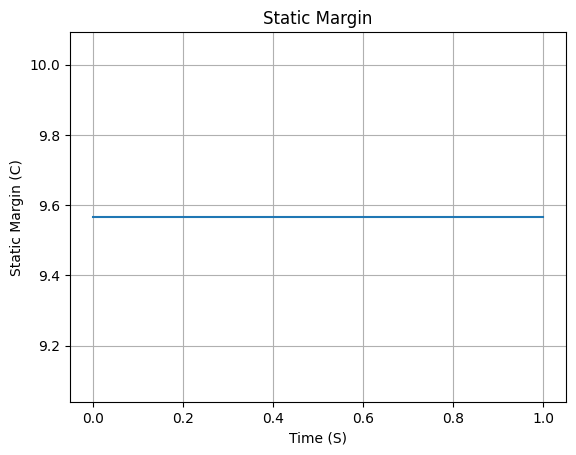

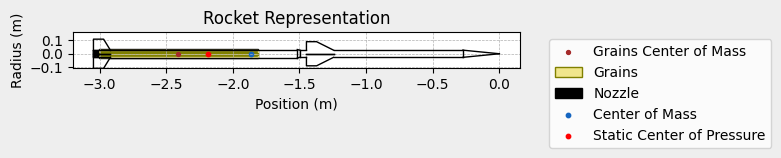

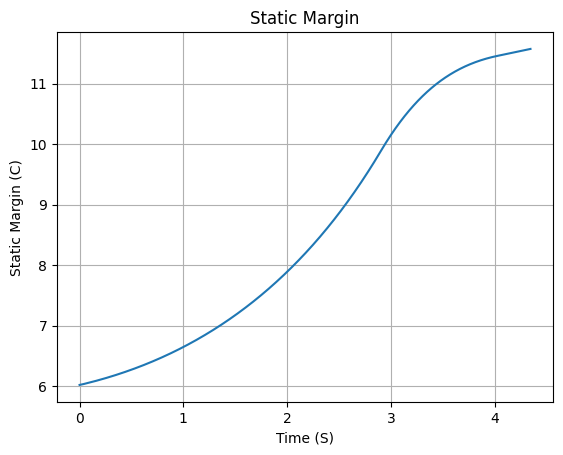


Inertia Details

Rocket Mass: 8.223 kg (without motor)
Rocket Dry Mass: 8.223 kg (with unloaded motor)
Rocket Loaded Mass: 12.747 kg
Rocket Structural Mass Ratio: 0.645
Rocket Inertia (with unloaded motor) 11: 4.165 kg*m2
Rocket Inertia (with unloaded motor) 22: 4.165 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.008 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.027 m
Rocket Frontal Area: 0.002290 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 1.484 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.844 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.300 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 13.124/rad
Tail Lift Coefficient Deri

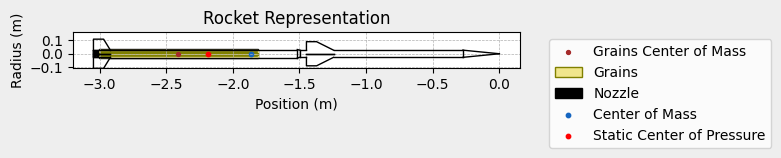


Mass Plots
----------------------------------------


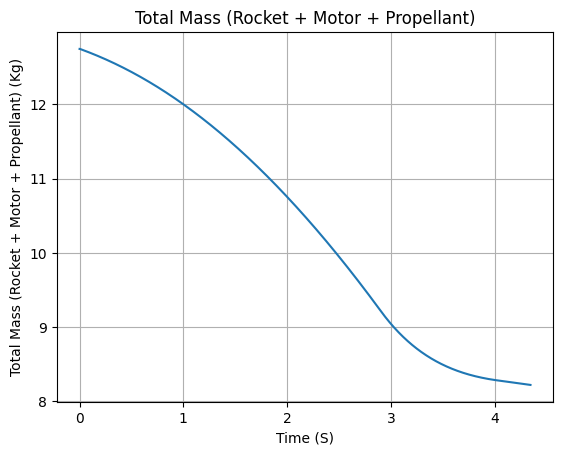

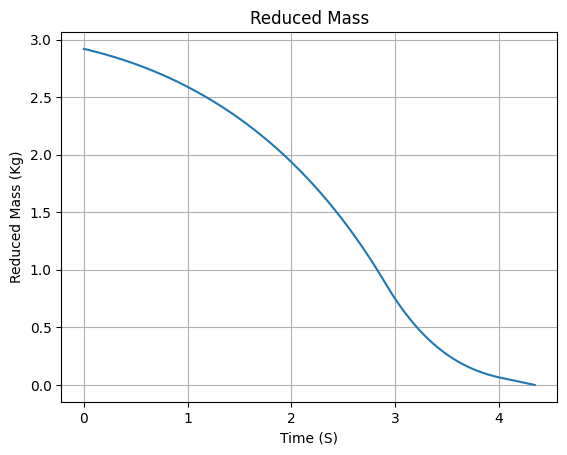


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


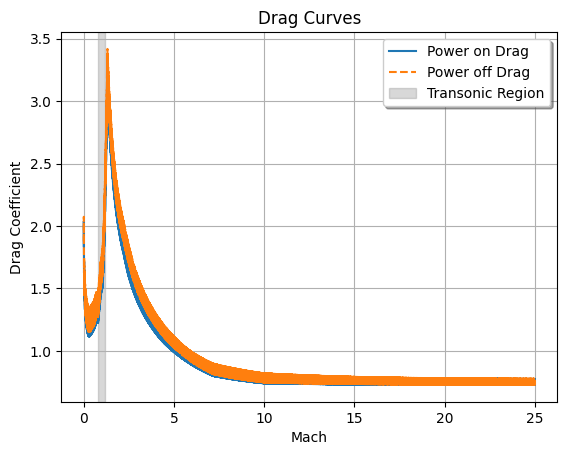


Stability Plots
--------------------


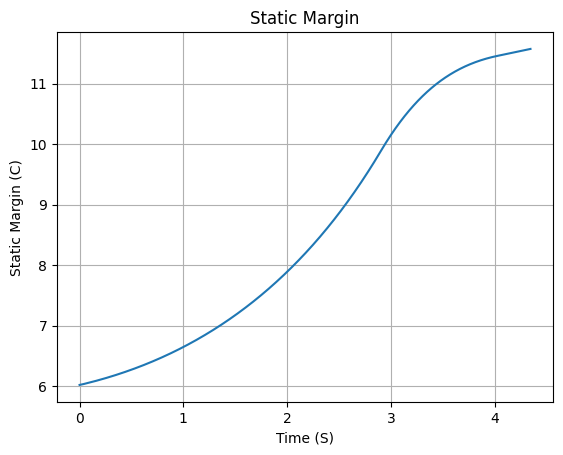

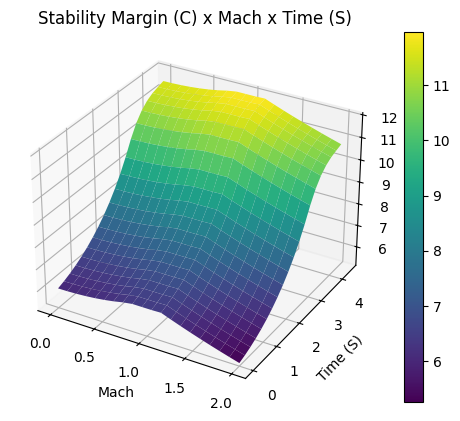


Thrust-to-Weight Plot
----------------------------------------


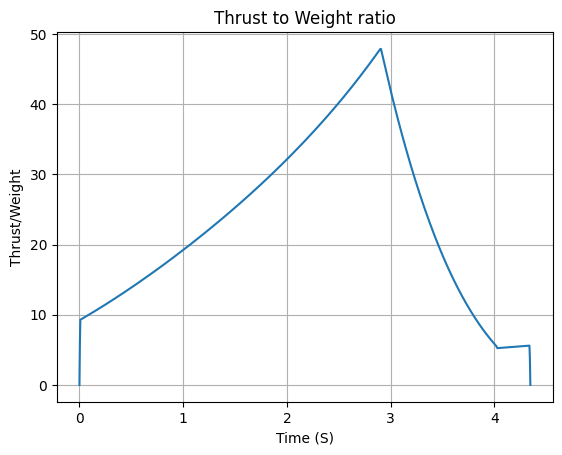

In [40]:
JUMPSustainer = Rocket(
    radius=54 / 2000,
    mass=2.4,
    inertia=(0.217, 0.217, 0.002),
    power_off_drag="./SustainerCDPowerOFF.csv",
    power_on_drag="./SustainerCDPowerON.csv",
    center_of_mass_without_motor=-0.66675,
    coordinate_system_orientation="tail_to_nose"
    )
JUMPSustainer.add_motor(SustainerMotor, position=(-1.5+0.04))

sustainernose_cone = JUMPSustainer.add_nose(
    length=0.27432, kind="conical", position=0
)

sustainerfin_set = JUMPSustainer.add_trapezoidal_fins(
    n=4,
    root_chord=0.2032,
    tip_chord=0.0762,
    span=0.0635,
    position=-1.2446,
    cant_angle=0.01,
    #airfoil=("../data/airfoils/NACA0012-radians.txt","radians"),
)


cd = 1.8
diameter = 0.6096

area = (diameter/2)*(diameter/2)*3.14
print(area)

main = JUMPSustainer.add_parachute(
    name="main",
    cd_s=area*cd,
    trigger=800,      # ejection altitude in meters
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    radius=1.5,
    height=1.5,
    porosity=0.0432,
)

cd = 0.6
diameter = 0.1016

area = (diameter/2)*(diameter/2)*3.14
print(area)

drogue = JUMPSustainer.add_parachute(
    name="drogue",
    cd_s=area,
    trigger="apogee",  # ejection at apogee
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    radius=0.1016,
    height=0.0762,
    porosity=0.0432,
)

JUMPSustainer.draw()
JUMPSustainer.plots.static_margin()
#JUMPSustainer.all_info()

#------------------------------------------------

JUMPSustainerNOMOTOR = Rocket(
    radius=54 / 2000,
    mass=4.48,
    inertia=(0.217, 0.217, 0.002),
    power_off_drag="./SustainerCDPowerOFF.csv",
    power_on_drag="./SustainerCDPowerON.csv",
    center_of_mass_without_motor=-0.66675,
    coordinate_system_orientation="tail_to_nose"
)

sustainernomotornose_cone = JUMPSustainerNOMOTOR.add_nose(
    length=0.27432, kind="conical", position=0
)

sustainernomotorfinset = JUMPSustainerNOMOTOR.add_trapezoidal_fins(
    n=4,
    root_chord=0.2032,
    tip_chord=0.0762,
    span=0.0635,
    position=-1.2446,
    cant_angle=0.01,
    #airfoil=("../data/airfoils/NACA0012-radians.txt","radians"),
)




JUMPSustainerNOMOTOR.draw()
JUMPSustainerNOMOTOR.plots.static_margin()
#JUMPSustainer.all_info()

#--------------------------------------

JUMPStack = Rocket(
    radius=54 / 2000,
    mass=8.223,
    inertia=(4.04, 4.04, 0.006),
    power_off_drag="./SustainerAndBoosterCDPowerOFF.csv",
    power_on_drag="./SustainerAndBoosterCDPowerON.csv",
    center_of_mass_without_motor=-1.5635224,
    coordinate_system_orientation="tail_to_nose"
    )
JUMPStack.add_motor(BoosterMotor, position=(-3.048+0.19))

stacknose_cone = JUMPStack.add_nose(
    length=0.27432, kind="conical", position=0
)

sustainerstackfin_set = JUMPStack.add_trapezoidal_fins(
   n=4,
    root_chord=0.2032,
    tip_chord=0.0762,
    span=0.0635,
    position=-1.2446,
    cant_angle=0.01,
    #airfoil=("../data/airfoils/NACA0012-radians.txt","radians"),
)

isc_transition = JUMPStack.add_tail(
    top_radius=54/2000,   # ~3 inch radius (forward tube)
    bottom_radius=63.5/2000, # ~2.1 inch radius (aft tube)
    length=0.01778,         # 8 cm transition length
    position=-1.4986        # 0.5 m from origin in your coordinate system
)

boosterfin_set = JUMPStack.add_trapezoidal_fins(
    n=4,
    root_chord=0.127,
    tip_chord=0.0762,
    span=0.08255,
    position=-2.9192,
    cant_angle=0.001,
    #airfoil=("../data/airfoils/NACA0012-radians.txt","radians"),
)

JUMPStack.draw()
JUMPStack.plots.static_margin()
JUMPStack.all_info()

In [51]:
from rocketpy.plots.compare import CompareFlights
import numpy as np
import matplotlib as mpl
import multiprocessing

#monte carlo attempts
#just gonna vary launch angle for now

railinclination = [88,1.5]
railheading = [270,90]
flightnum = 1
thisflightnum = 0

flights = []
landingcoords = []

randomnum = np.random.normal(railinclination[0],railinclination[1],1)
print(randomnum)

def runsim():
    print("running sim")
    StackFlight2 = Flight(
        rocket=JUMPStack, 
        environment=env, 
        rail_length=3.048, 
        inclination=np.random.normal(railinclination[0],railinclination[1],1)[0],#np.random.normal(railinclination,inclinationstd,1), 
        heading=np.random.normal(railheading[0],railheading[1],1)[0],
        max_time = BoosterMotor.burn_out_time
        )

    #StackFlight2.info()
    #StackFlight2.plots.trajectory_3d()
    flights.append(StackFlight2)

    stagingdelay = 8

    SustainerNOMOTORFlight2 = Flight(
        rocket=JUMPSustainerNOMOTOR, 
        environment=env, 
        initial_solution=StackFlight2,
        rail_length=0.01, 
        inclination=StackFlight2.attitude_angle(BoosterMotor.burn_out_time-0.01), 
        heading=StackFlight2.path_angle(BoosterMotor.burn_out_time-0.01),
        max_time = stagingdelay+BoosterMotor.burn_out_time
    )

    flights.append(SustainerNOMOTORFlight2)

    sustainerstartcondition = SustainerNOMOTORFlight2.solution[-2][:]
    sustainerstartcondition[0] = 0

    SustainerFlight2 = Flight(
        rocket=JUMPSustainer, 
        environment=env, 
        initial_solution=sustainerstartcondition,
        rail_length=0.01, 
        inclination=SustainerNOMOTORFlight2.attitude_angle(stagingdelay+BoosterMotor.burn_out_time-0.01), 
        heading=SustainerNOMOTORFlight2.path_angle(stagingdelay+BoosterMotor.burn_out_time-0.01),
        #max_time = 15
    )
    for entry in SustainerFlight2.solution:
        entry[0] = entry[0]+stagingdelay+BoosterMotor.burn_out_time

    flights.append(SustainerFlight2)
    landingcoords.append([SustainerFlight2.x_impact,SustainerFlight2.y_impact])
    print(SustainerFlight2.apogee)
    print("ran sim")
    

    

while thisflightnum < flightnum:
    runsim()
    thisflightnum = thisflightnum + 1 
    print(thisflightnum)
    





[87.18127249]
running sim
42338.562029470966
ran sim
1


[[np.float64(-5623.048883434927), np.float64(-2579.885947130975)]]


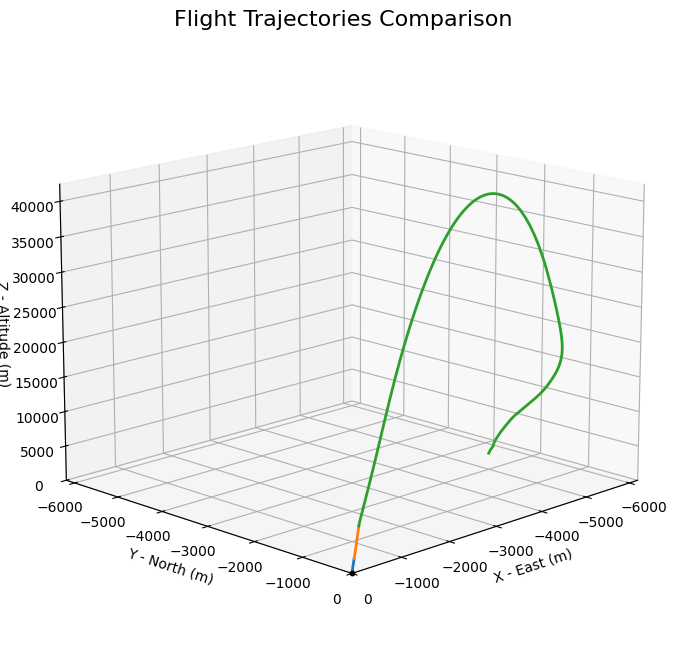

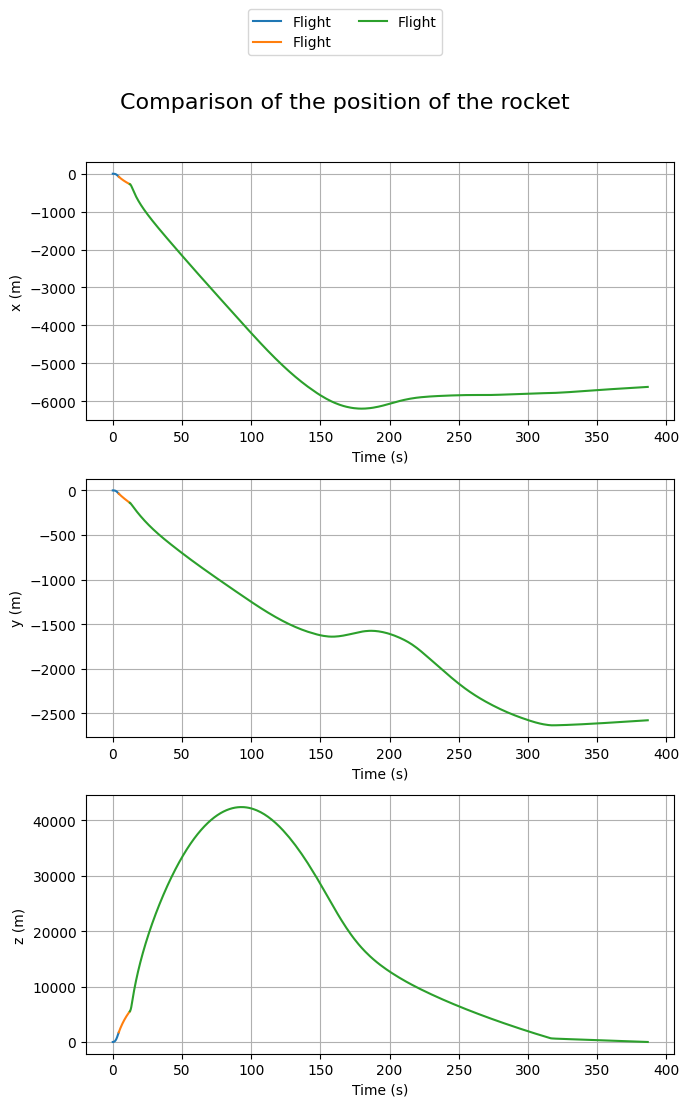

In [48]:
print(landingcoords)
comparison = CompareFlights(flights)
# #SustainerFlight2.info()
comparison.trajectories_3d()
#comparison.trajectories_2d()
comparison.positions()
#comparison.stability_margin()